# Analysis of model training with Vision Transformers

## File structure for upload:
First key: Batch size
Second key: run 


In [1]:
from keras.datasets   			    import cifar10
from tensorflow.keras 			    import regularizers
from scipy.stats      			    import norm
from IPython.display  			    import clear_output
from google.colab     			    import drive
from keras.models     			    import Sequential
from keras.layers     			    import Dense,Dropout,Activation,Flatten
from keras.layers     			    import Conv1D,MaxPooling1D,Conv2D,MaxPooling2D
from keras.utils      			    import plot_model
from keras.utils      			    import np_utils
from matplotlib.lines               import Line2D
# from hilbertcurve.hilbertcurve	import HilbertCurve

import matplotlib.pyplot  as plt
import numpy              as np
import datetime           as dt
import keras.backend      as k
import sklearn            as skl
import scipy.stats        as stats
import matplotlib.pyplot  as plt
import tensorflow         as tf

import copy
import random 
import cv2
import pickle #credits to stack overflow user= blender
import math 
import os

savefiles = 0

tf.test.gpu_device_name()

startdate = dt.datetime.now()
timestamp = startdate.strftime('%d%m_%H%M%S')

# dataname  = 'cifar10'
dataname = "imagenette"

my_transform_names = ['Hilbert','Dotprint','2D']

# identifier= dataname + '_' + transform
# filename  = identifier+"_"+timestamp

file_location = 'drive/MyDrive/AI_Research/Hilbert_AppliedIntelligence/ViT/Cluster_results/Imagenette'
if os.getcwd().find(file_location) != -1:
    print("Already in proper working directory")
else:
    drive.mount('/content/drive/')
    print("Current location:", os.getcwd())
    os.chdir(file_location)

print("Working directory: %s" %os.getcwd())


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Current location: /content
Working directory: /content/drive/MyDrive/AI_Research/Hilbert_AppliedIntelligence/ViT/Cluster_results/Imagenette


In [2]:
def check_hypers(ref_list, new_list):
    for my_key in list(ref_list.keys()):
        if my_key in list(new_list.keys()):
            if new_list[my_key] == ref_list[my_key]:
                continue
            else:
                print("Value difference: %s: %.2f != %.2f" %(my_key, new_list[my_key], ref_list[my_key]))
                return 0
        else:
            print("Key %s not present in target dataframe" %(my_key))
    return 1

In [3]:
def does_exist(substring, stringlist):
    for string in stringlist:
        if string.find(substring) != -1:
            return string
    return 0

def list_exist(substring, stringlist):
    my_names = list()
    for string in stringlist:
        if string.find(substring) != -1:
            my_names.append(string)
    return my_names

### Get transformation name

In [4]:
def get_transform_from_dir(name):
    for my_transform in my_transform_names:
        if name.find(my_transform) != -1:
            return my_transform
    return 0

## Load data from output-files and construct dataframe

In [5]:
def unpack_files(filename, my_file, my_dataframe, my_transform, my_epoch=0):
    if my_epoch: 
        print("setting my epoch to fixed selection: %i" %my_epoch)
    else:
        my_epoch = my_file["Hyperparameters"]["Epochs"]
        print("Variable selection of epochs: %i" %my_epoch)

    my_batch = my_file["Hyperparameters"]["Batch"]
    my_run   = my_file["Hyperparameters"]["run"]
    my_lr    = my_file["Hyperparameters"]["lr"]
    my_data  = my_file["Hyperparameters"]["Data"]
    if my_transform == "ViT_2D":
        my_trans = my_transform
    else:
        my_trans = my_file["Hyperparameters"]["Transformation"]
    if list(my_dataframe.keys()):
        if check_hypers(my_dataframe["Hyperparameters"], my_file["Hyperparameters"]):
            if my_batch in list(my_dataframe.keys()):
                if my_trans in list(my_dataframe[my_batch].keys()):
                    run_counter = max(list(my_dataframe[my_batch][my_trans].keys()))+1
                    my_dataframe[my_batch][my_trans][run_counter] = {}
                    my_dataframe[my_batch][my_trans][run_counter]["train_accuracy"] = my_file["train_accuracy"]
                    my_dataframe[my_batch][my_trans][run_counter]["train_loss"] = my_file["train_loss"]
                    # my_dataframe[my_batch][my_trans][run_counter]["train_top_k_accuracy"] = my_file["train_top_k_accuracy"]

                    my_dataframe[my_batch][my_trans][run_counter]["val_accuracy"] = my_file["val_accuracy"]
                    my_dataframe[my_batch][my_trans][run_counter]["val_loss"] = my_file["val_loss"]
                    # my_dataframe[my_batch][my_trans][run_counter]["val_top_k_accuracy"] = my_file["val_top_k_accuracy"]
                else:
                    run_counter = 0
                    my_dataframe[my_batch][my_trans] = {}
                    my_dataframe[my_batch][my_trans][run_counter] = {}
                    my_dataframe[my_batch][my_trans][run_counter]["train_accuracy"] = my_file["train_accuracy"]
                    my_dataframe[my_batch][my_trans][run_counter]["train_loss"] = my_file["train_loss"]
                    # my_dataframe[my_batch][my_trans][run_counter]["train_top_k_accuracy"] = my_file["train_top_k_accuracy"]

                    my_dataframe[my_batch][my_trans][run_counter]["val_accuracy"] = my_file["val_accuracy"]
                    my_dataframe[my_batch][my_trans][run_counter]["val_loss"] = my_file["val_loss"]
                    # my_dataframe[my_batch][my_trans][run_counter]["val_top_k_accuracy"] = my_file["val_top_k_accuracy"]
            else:
                run_counter = 0
                my_dataframe[my_batch] = {}
                my_dataframe[my_batch][my_trans] = {}
                my_dataframe[my_batch][my_trans][run_counter] = {}
                my_dataframe[my_batch][my_trans][run_counter]["train_accuracy"] = my_file["train_accuracy"]
                my_dataframe[my_batch][my_trans][run_counter]["train_loss"] = my_file["train_loss"]
                # my_dataframe[my_batch][my_trans][run_counter]["train_top_k_accuracy"] = my_file["train_top_k_accuracy"]

                my_dataframe[my_batch][my_trans][run_counter]["val_accuracy"] = my_file["val_accuracy"]
                my_dataframe[my_batch][my_trans][run_counter]["val_loss"] = my_file["val_loss"]
                # my_dataframe[my_batch][my_trans][run_counter]["val_top_k_accuracy"] = my_file["val_top_k_accuracy"]
    else:
        print("No keys in dataframe yet")
        if my_file["Hyperparameters"]["Epochs"] == my_epoch:
            my_dataframe["Hyperparameters"] = {}
            my_dataframe["Hyperparameters"]["Epochs"] = my_epoch
            my_dataframe["Hyperparameters"]["lr"] = my_lr
            my_dataframe["Hyperparameters"]["Data"] = my_data

            run_counter = 0

            my_dataframe[my_batch] = {}
            my_dataframe[my_batch][my_trans] = {}
            my_dataframe[my_batch][my_trans][run_counter] = {}
            # np array works, but easier initially to analyse dict
            # my_dataframe[my_batch][my_trans][run_counter] = np.array([my_file["train_accuracy"],my_file["val_accuracy"],my_file["train_loss"],my_file["val_loss"],my_file["test_accuracy"]])
            my_dataframe[my_batch][my_trans][run_counter]["train_accuracy"] = my_file["train_accuracy"]
            my_dataframe[my_batch][my_trans][run_counter]["train_loss"] = my_file["train_loss"]
            # my_dataframe[my_batch][my_trans][run_counter]["train_top_k_accuracy"] = my_file["train_top_k_accuracy"]

            my_dataframe[my_batch][my_trans][run_counter]["val_accuracy"] = my_file["val_accuracy"]
            my_dataframe[my_batch][my_trans][run_counter]["val_loss"] = my_file["val_loss"]
            # my_dataframe[my_batch][my_trans][run_counter]["val_top_k_accuracy"] = my_file["val_top_k_accuracy"]
    return my_dataframe
#    my_dataframe[my_batch][run_counter] = np.array(my_file["Training_accuracy"],my_file["validation_accuracy"],my_file["training_loss"],my_file["validation_loss"],my_file["test_accuracy"])

## Set selection of hyperparameters (optional)

## Load data from files

In [6]:
my_dataset = {}

if os.getcwd().find(file_location) != -1:
    print("Already in proper working directory")
else:
    os.chdir(file_location)

my_dirs = list()
my_dirs = list_exist(dataname, os.listdir())
print(my_dirs)

if my_dirs:
    for my_dir in my_dirs:
        transform = get_transform_from_dir(my_dir)
        if transform:
            print("Transformation: ", transform)
            os.chdir(my_dir)
            file_names = list_exist("Features", os.listdir())
            for my_file in file_names:
                print("Unpacking file %s from directory %s" %(my_file, my_dir))
                with (open(my_file,"rb")) as handle:
                    my_results = pickle.load(handle)
                    handle.close()
                ## Get hyperparameters from datafile
                epochs = my_results['Hyperparameters']["Epochs"]
                # epochs = 150
                ## unpack datafile
                my_dataset = unpack_files(my_file, my_results, my_dataset, transform, my_epoch = epochs)
                del(my_results)
            os.chdir("..")
        else:
            print("Transformation of directory %s not found in allowed list" %my_dir)
else: 
    print("No data directories for dataset %s found in working directory %s" %(dataname, os.listdir()))


Already in proper working directory
['ViT_imagenette_2D_2705_220006', 'ViT_imagenette_Dotprint_2705_212018', 'ViT_imagenette_Hilbert_2705_202851', 'ViT_imagenette_Hilbert_2805_130039', 'ViT_imagenette_Dotprint_2805_130058']
Transformation:  2D
Unpacking file Features_10.dat from directory ViT_imagenette_2D_2705_220006
setting my epoch to fixed selection: 10
No keys in dataframe yet
Unpacking file Features_3.dat from directory ViT_imagenette_2D_2705_220006
setting my epoch to fixed selection: 10
Unpacking file Features_5.dat from directory ViT_imagenette_2D_2705_220006
setting my epoch to fixed selection: 10
Unpacking file Features_2.dat from directory ViT_imagenette_2D_2705_220006
setting my epoch to fixed selection: 10
Unpacking file Features_7.dat from directory ViT_imagenette_2D_2705_220006
setting my epoch to fixed selection: 10
Unpacking file Features_9.dat from directory ViT_imagenette_2D_2705_220006
setting my epoch to fixed selection: 10
Unpacking file Features_4.dat from direc

In [7]:
print(my_dirs)

['ViT_imagenette_2D_2705_220006', 'ViT_imagenette_Dotprint_2705_212018', 'ViT_imagenette_Hilbert_2705_202851', 'ViT_imagenette_Hilbert_2805_130039', 'ViT_imagenette_Dotprint_2805_130058']


## Analysis

In [8]:
my_epochs = my_dataset["Hyperparameters"]["Epochs"]

my_batches = list(my_dataset.keys())[1:]
my_transforms = list(my_dataset[my_batches[0]].keys())
my_runs = list(my_dataset[my_batches[0]][my_transforms[0]].keys())
my_metrics = list(my_dataset[my_batches[0]][my_transforms[0]][my_runs[0]].keys())

In [9]:
# print(len(my_dataset[my_batches[0]][my_transforms[0]][my_runs[0]][my_metrics[0]]))
print(my_batches)
print(my_transforms)
print(my_runs)
print(my_metrics)

[50, 10, 20]
['2D']
[0, 1, 2, 3, 4]
['train_accuracy', 'train_loss', 'val_accuracy', 'val_loss']


## Rename Dotprint to Flatten

In [10]:
for key in list(my_dataset.keys()):
    for my_key in list(my_dataset[key].keys()):
        if my_key == "Dotprint":
            my_dataset[key]["Flatten"] = my_dataset[key]["Dotprint"]
            del(my_dataset[key]["Dotprint"])
    print (my_dataset[key].keys())

my_transform_names = ['Hilbert','Flatten']

dict_keys(['Epochs', 'lr', 'Data'])
dict_keys(['2D'])
dict_keys(['2D', 'Hilbert', 'Flatten'])
dict_keys(['2D'])


In [11]:
from matplotlib.lines import Line2D
# Figure Formatting:
####################
def set_figure_size(row, col):
    width = 17.5*int(row/2)+1
    height= 8*int(col/2)+1
    return (width,height)

figure_size = (17.5,8)

# font sizes
fs = 20 #fontsize
ts = 25 #titlesize
ls = 15 #legendsize
tick_size = 15

# visual settings
ms = 10
lw = 2

# Markers and linetypes
my_markers = ['o','s','p','h','+','x','v','>','<','^']
line_styles = ["solid","dashed","dotted","dashdot"]
my_colors = ["C0","C9", "C3","C6","C2","C8"]

## Visualization

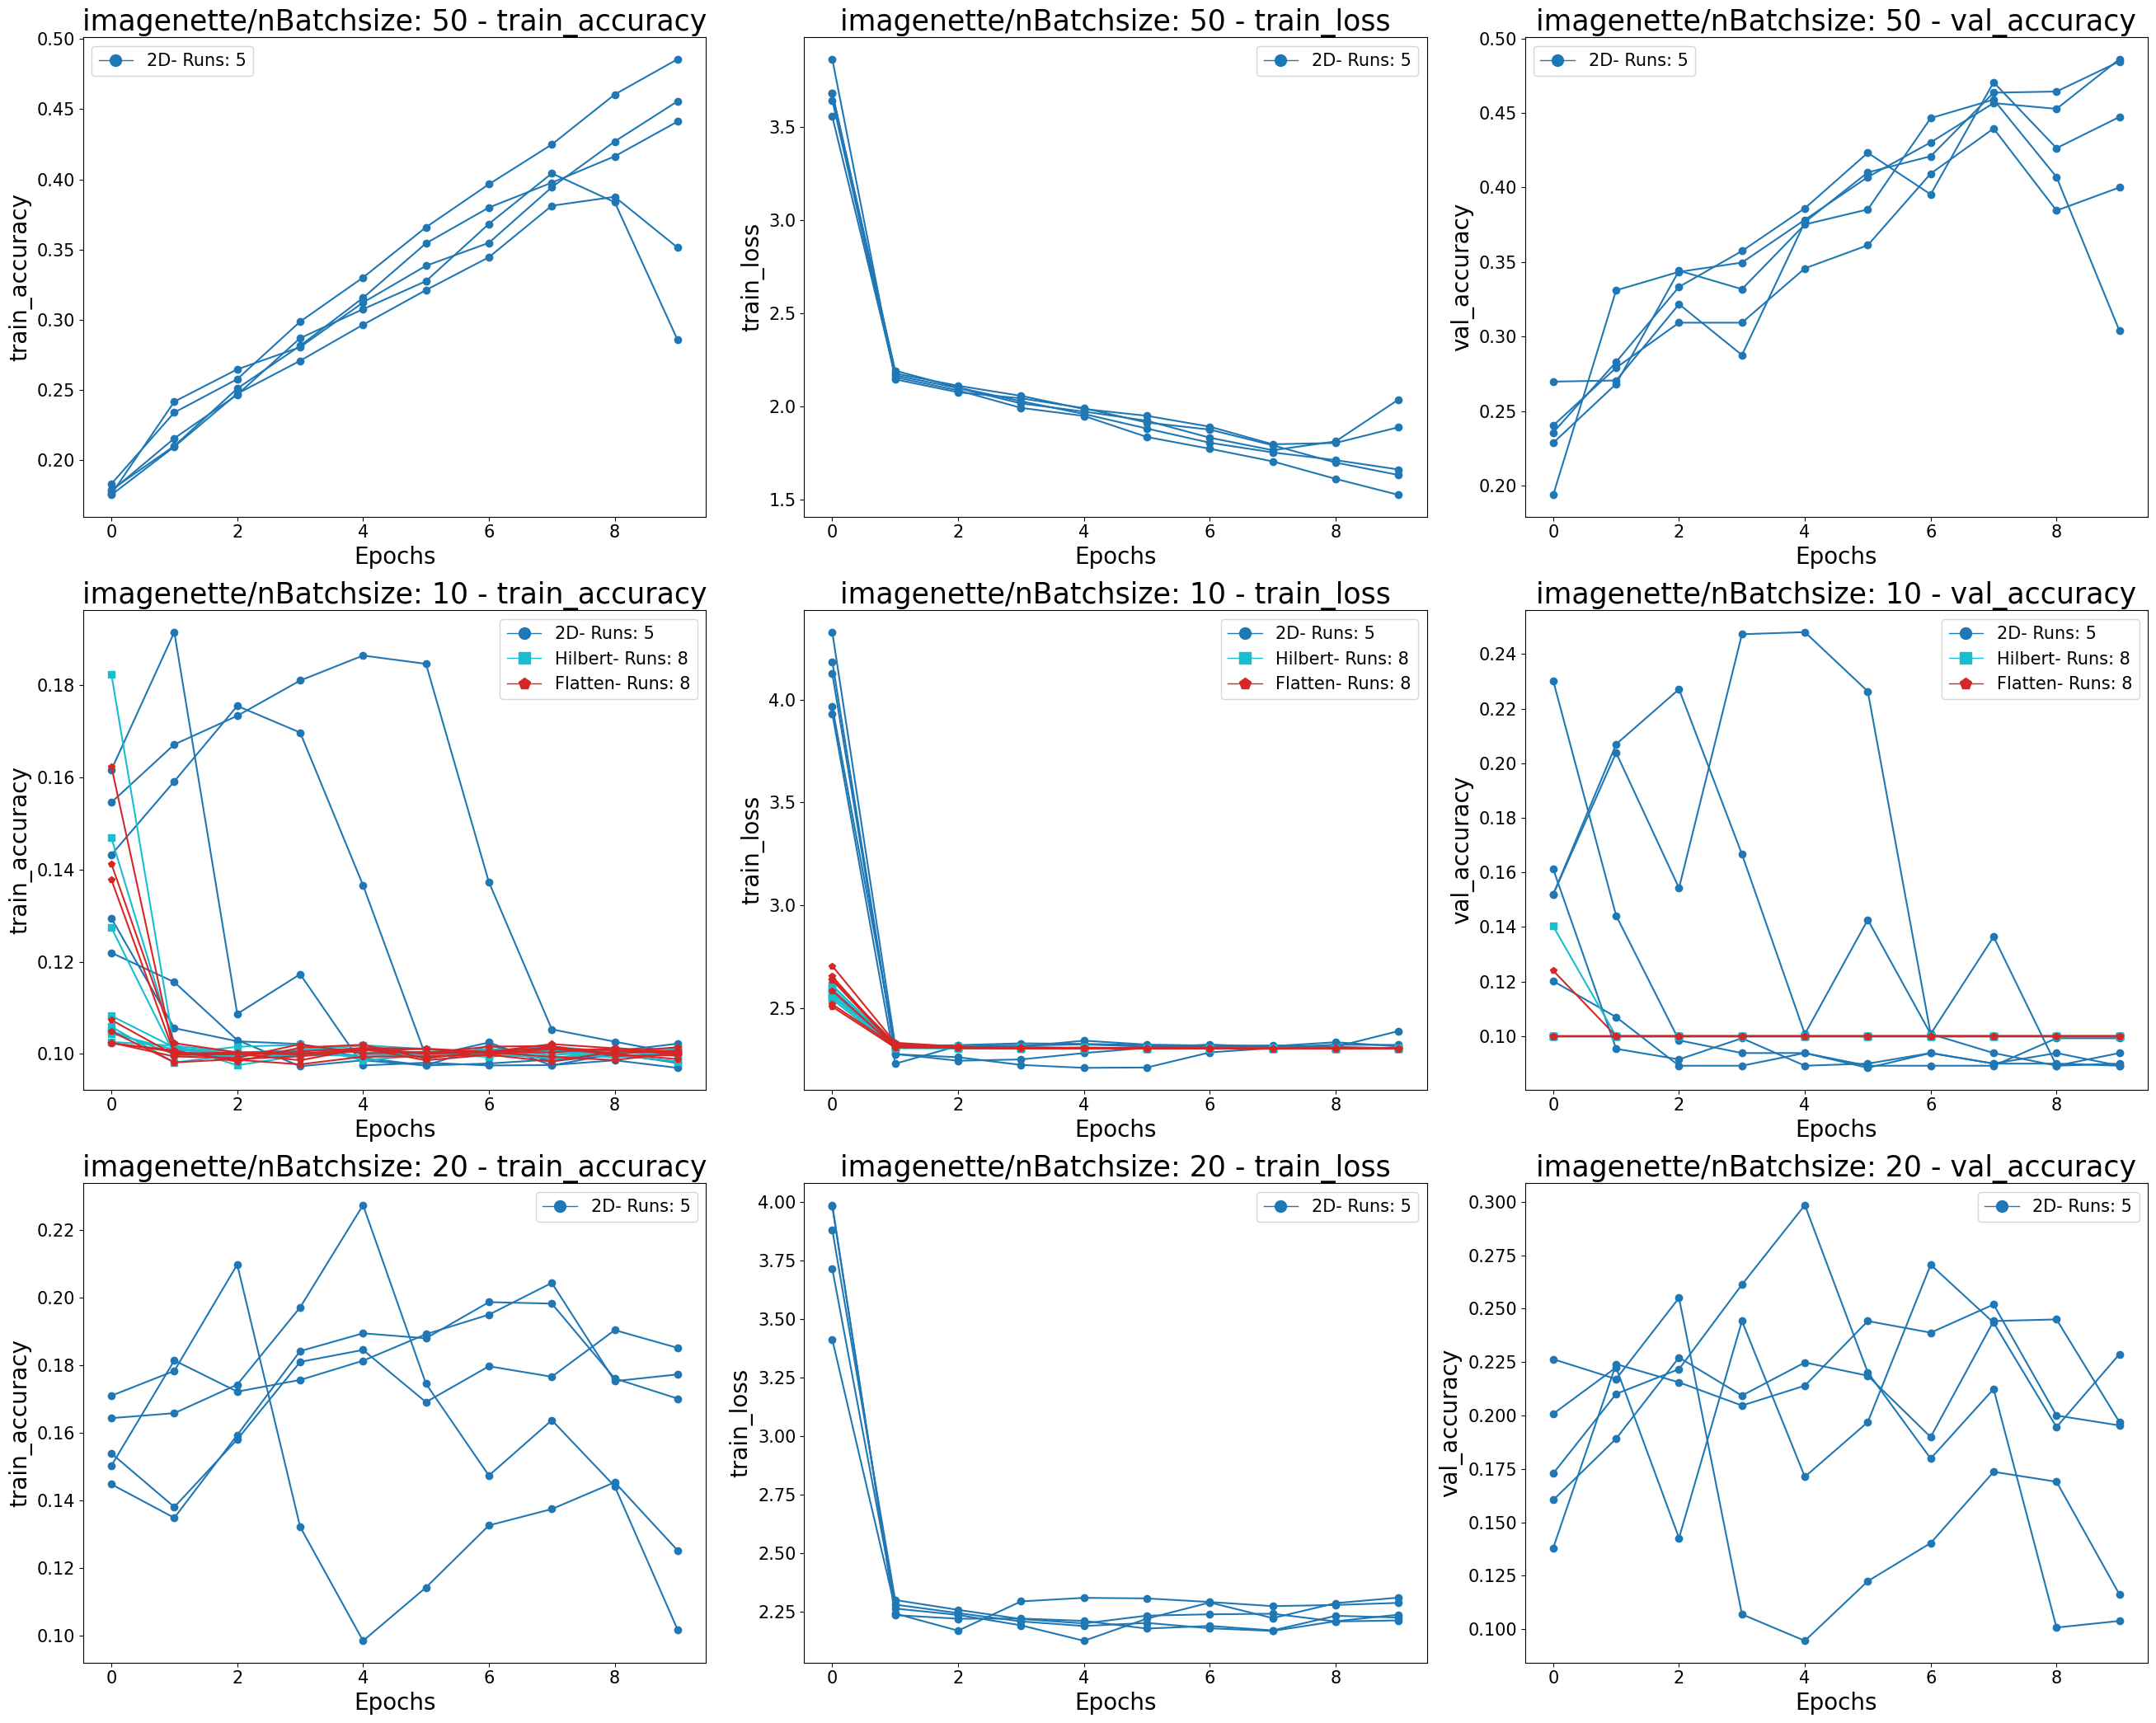

In [13]:
# fig, axs = plt.subplots(len(my_batches),len(my_metrics[:-1]), figsize= set_figure_size(len(my_batches),len(my_metrics[:-1])))
if len(my_batches) > 1:
    fig, axs = plt.subplots(len(my_batches),len(my_metrics[:-1]), figsize= (len(my_batches)/2*17.5,3*7))
else:
    fig, axs = plt.subplots(len(my_batches),len(my_metrics[:-1]), figsize= (2*17.5,8))

row_nb = 0
col_nb = 0

for my_batch in my_batches:
    color_index = 0
    col_nb = 0
    my_transforms = list(my_dataset[my_batch].keys())
    for my_metric in my_metrics[:-1]:
        legend_string = list()
        color_index = 0
        for my_transform in my_transforms:
            my_runs = list(my_dataset[my_batch][my_transform].keys())
            line_index = 0
            # print(my_runs)    
            for my_run in my_runs:
                ## Transformation 1
                if len(my_batches) > 1:
                    axs[row_nb][col_nb].plot(
                        range(my_epochs),
                        my_dataset[my_batch][my_transform][my_run][my_metric],
                        color = my_colors[color_index],
                        linestyle = line_styles[line_index],
                        marker = my_markers[color_index],
                        # label = my_transform
                        )
                else:
                    axs[col_nb].plot(
                        range(my_epochs),
                        my_dataset[my_batch][my_transform][my_run][my_metric],
                        color = my_colors[color_index],
                        linestyle = line_styles[line_index],
                        marker = my_markers[color_index],
                        # label = my_transform
                        )
                    
            legend_string.append(Line2D([0], [0],
                                color = my_colors[color_index],
                                linestyle = line_styles[line_index],
                                marker = my_markers[color_index],
                                markersize = ms,
                                lw=1,
                                label="%s- Runs: %i" %(my_transform,len(my_runs))
                                )
            )
            color_index += 1
            if line_index:
                line_index = 0
            else:
                line_index = 1
            
            if len(my_batches) > 1:                
                axs[row_nb][col_nb].set_title(dataname+"/nBatchsize: %i - %s" %(my_batch, my_metric), fontsize=ts)
                axs[row_nb][col_nb].set_xlabel("Epochs", fontsize=fs)
                axs[row_nb][col_nb].set_ylabel(my_metric, fontsize=fs)
                axs[row_nb][col_nb].tick_params(axis='both', labelsize=tick_size)
                axs[row_nb][col_nb].legend(handles=legend_string, frameon=True, loc='best', fontsize=ls)
                # axs[row_nb][col_nb].legend(fontsize=ls)
            else:
                axs[col_nb].set_title(dataname+"/nBatchsize: %i - %s" %(my_batch, my_metric), fontsize=ts)
                axs[col_nb].set_xlabel("Epochs", fontsize=fs)
                axs[col_nb].set_ylabel(my_metric, fontsize=fs)
                axs[col_nb].tick_params(axis='both', labelsize=tick_size)
                axs[col_nb].legend(handles=legend_string, frameon=True, loc='best', fontsize=ls)
                # axs[row_nb][col_nb].legend(fontsize=ls)

        col_nb += 1
    row_nb += 1

fig.tight_layout()

if 0:
    fig.savefig("Fig_1.png",dpi = 100, bbox_inches="tight")

fig.show()


## Averaged results

In [ ]:
# fig, axs = plt.subplots(len(my_batches),len(my_metrics[:-1]), figsize= set_figure_size(len(my_batches),len(my_metrics[:-1])))
if len(my_batches) > 1:
    fig, axs = plt.subplots(len(my_batches),len(my_metrics[:-1]), figsize= (len(my_batches)/2*17.5,2*9))
else:
    fig, axs = plt.subplots(len(my_batches),len(my_metrics[:-1]), figsize= (2*17.5,8))

row_nb = 0
col_nb = 0

expected_values  = {}
variation_values = {}

for my_batch in my_batches:
    color_index = 0
    col_nb = 0
    my_transforms = list(my_dataset[my_batch].keys())
    expected_values[my_batch]  = {}
    variation_values[my_batch] = {}
    for my_metric in my_metrics[:-1]:
        legend_string = list()
        expected_values[my_batch][my_metric]  = {}
        variation_values[my_batch][my_metric] = {}
        for my_transform in my_transforms:
            my_runs = list(my_dataset[my_batch][my_transform].keys())    
            expected_values[my_batch][my_metric][my_transform]  = list()
            variation_values[my_batch][my_metric][my_transform] = list()
            # for my_run in my_runs:
                ## Transformation 1
            my_epochs = len(my_dataset[my_batch][my_transform][my_runs[0]][my_metric])
            exp_vals = list()
            var_vals = list()
            for my_range in range(my_epochs):
                my_exp_val, my_var = norm.fit([my_dataset[my_batch][my_transform][my_run][my_metric][my_range] for my_run in my_runs])
                exp_vals.append(my_exp_val)
                var_vals.append(my_var)
            if len(my_batches) > 1:
                axs[row_nb][col_nb].errorbar(
                    range(my_epochs),
                    exp_vals,
                    var_vals,
                    color="C"+str(color_index),
                    linestyle = line_styles[0],
                    marker = my_markers[0],
                    # label = my_transform
                    )
            else:
                axs[col_nb].errorbar(
                    range(my_epochs),
                    exp_vals,
                    var_vals,
                    color="C"+str(color_index),
                    linestyle = line_styles[0],
                    marker = my_markers[0],
                    # label = my_transform
                    )
            expected_values[my_batch][my_metric][my_transform]  = exp_vals
            variation_values[my_batch][my_metric][my_transform] = var_vals

            legend_string.append(Line2D([0], [0],
                                color='C'+str(color_index),
                                marker = my_markers[0],
                                markersize = ms,
                                linestyle=line_styles[0],
                                lw=1,
                                label="%s- Runs: %i" %(my_transform,len(my_runs))
                                )
            )
            color_index += 1
            
            if len(my_batches) > 1:                
                axs[row_nb][col_nb].set_title(dataname+"/nBatchsize: %i - %s" %(my_batch, my_metric), fontsize=ts)
                axs[row_nb][col_nb].set_xlabel("Epochs", fontsize=fs)
                axs[row_nb][col_nb].set_ylabel(my_metric, fontsize=fs)
                axs[row_nb][col_nb].tick_params(axis='both', labelsize=tick_size)
                axs[row_nb][col_nb].legend(handles=legend_string, frameon=True, loc='best', fontsize=ls)
                # axs[row_nb][col_nb].legend(fontsize=ls)
            else:
                axs[col_nb].set_title(dataname+"/nBatchsize: %i - %s" %(my_batch, my_metric), fontsize=ts)
                axs[col_nb].set_xlabel("Epochs", fontsize=fs)
                axs[col_nb].set_ylabel(my_metric, fontsize=fs)
                axs[col_nb].tick_params(axis='both', labelsize=tick_size)
                axs[col_nb].legend(handles=legend_string, frameon=True, loc='best', fontsize=ls)
                # axs[row_nb][col_nb].legend(fontsize=ls)

        col_nb += 1
    row_nb += 1

fig.tight_layout()

if 0:
    fig.savefig("Fig_2.png",dpi = 100, bbox_inches="tight")

fig.show()


In [ ]:
if len(my_batches) > 1:
    fig, axs = plt.subplots(len(my_batches),len(my_metrics[:-1]), figsize= (len(my_batches)*17.5,2*9))
else:
    fig, axs = plt.subplots(len(my_batches),len(my_metrics[:-1]), figsize= (2*17.5,8))

row_nb = 0
col_nb = 0

for my_batch in my_batches:
    color_index = 0
    col_nb = 0
    my_transforms = list(my_dataset[my_batch].keys())
    for my_metric in my_metrics[:-1]:
        legend_string = list()
        temp_exp_set = np.zeros((my_epochs))
        temp_var_set = np.zeros((my_epochs))
        sign = 1
        for my_transform in my_transforms:
            my_runs = list(my_dataset[my_batch][my_transforms[0]].keys())
            temp_exp_set += sign*(np.array(expected_values[my_batch][my_metric][my_transform]))
            temp_var_set += np.array(variation_values[my_batch][my_metric][my_transform])
            if sign:
                sign = -1
        if len(my_batches) > 1:
            axs[row_nb][col_nb].errorbar(
                range(my_epochs),
                temp_exp_set,
                temp_var_set,
                color="C"+str(color_index),
                linestyle = line_styles[0],
                marker = my_markers[0],
                )
        else:
            axs[col_nb].errorbar(
                range(my_epochs),
                temp_exp_set,
                temp_var_set,
                color="C"+str(color_index),
                linestyle = line_styles[0],
                marker = my_markers[0],
                )
        if len(my_batches) > 1:                
            axs[row_nb][col_nb].set_title(dataname+" Difference\nBatchsize: %i - %s" %(my_batch, my_metric), fontsize=ts)
            axs[row_nb][col_nb].set_xlabel("Epochs", fontsize=fs)
            axs[row_nb][col_nb].set_ylabel(my_metric, fontsize=fs)
            axs[row_nb][col_nb].tick_params(axis='both', labelsize=tick_size)
            axs[row_nb][col_nb].legend(handles=legend_string, frameon=True, loc='best', fontsize=ls)
            # axs[row_nb][col_nb].legend(fontsize=ls)
        else:
            axs[col_nb].set_title(dataname+" Difference\nBatchsize: %i - %s" %(my_batch, my_metric), fontsize=ts)
            axs[col_nb].set_xlabel("Epochs", fontsize=fs)
            axs[col_nb].set_ylabel(my_metric, fontsize=fs)
            axs[col_nb].tick_params(axis='both', labelsize=tick_size)
            axs[col_nb].legend(handles=legend_string, frameon=True, loc='best', fontsize=ls)
            # axs[row_nb][col_nb].legend(fontsize=ls)

        col_nb += 1
    row_nb += 1

fig.tight_layout()

if 0:
    fig.savefig("Fig_3.png",dpi = 100, bbox_inches="tight")

fig.show()


## Overfitting measure